#### Competitor Visualization & Positioning Analysis

**Goal**  
Create visual comparisons and gap analyses from the scored dataset (2023–2025) to:
- Show developer strengths/weaknesses
- Identify clear market gaps (e.g., low first-time appeal in mid-tier areas)
- Highlight positioning opportunities for mid-tier sustainable projects

**Input:** `data/cleaned_competitor_projects_2023_2025.csv`  
**Output:** Figures saved to `figures/` folder + key insights for final recommendations

#### Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Create figures folder if missing
os.makedirs('figures', exist_ok=True)

print("Visualization libraries ready.")

Visualization libraries ready.


#### Load Cleaned Data (Code)


In [3]:
INPUT_PATH = 'data/cleaned_competitor_projects_2023_2025.csv'
df = pd.read_csv(INPUT_PATH)

print(f"Loaded {len(df)} projects")
print("Columns:", df.columns.tolist())
print("\nSample:")
df.head(3)

Loaded 80 projects
Columns: ['project_id', 'developer', 'emirate', 'area', 'property_type', 'status', 'launch_year', 'handover_year', 'avg_pps_aed', 'sustainability_score', 'first_time_focus', 'total_units_planned', 'project_name', 'clipped_price', 'clipped_units', 'handover_reliability_score', 'pps_normalized', 'pps_score', 'first_time_appeal_score', 'sustainability_strength', 'positioning_index']

Sample:


,project_id,developer,emirate,area,property_type,status,launch_year,handover_year,avg_pps_aed,sustainability_score,...,total_units_planned,project_name,clipped_price,clipped_units,handover_reliability_score,pps_normalized,pps_score,first_time_appeal_score,sustainability_strength,positioning_index
0,1,Emaar,Dubai,Palm Jumeirah,Apartment,Ready,2024,2024,2659.0,0,...,500,Emaar Bay 32,0,0,10.0,0.756335,2.436647,1.0,0.0,4.0
1,2,DAMAC,Dubai,Jumeirah Village Circle (JVC),Apartment,Ready,2025,2025,1331.0,0,...,500,DAMAC Pinnacle 12,0,0,10.0,0.109162,8.908382,3.6,0.0,4.9
2,3,Emaar,Dubai,Business Bay,Apartment,Off-plan,2024,2025,2027.0,0,...,500,Emaar Residences 12,0,0,7.0,0.448343,5.516569,2.2,0.0,3.5


#### 1. Average Positioning Scores by Developer

In [4]:
score_cols = ['first_time_appeal_score', 'handover_reliability_score',
              'sustainability_strength', 'positioning_index']

avg_scores = df.groupby('developer')[score_cols].mean().round(1).reset_index()

fig = px.bar(
    avg_scores.melt(id_vars='developer', var_name='Score Type', value_name='Average Score'),
    x='developer', y='Average Score', color='Score Type',
    barmode='group',
    title="Average Competitive Scores by Developer (2023–2025)",
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

# Save
fig.write_image("figures/1_avg_scores_by_developer.png", scale=2)

Resorting to unclean kill browser.


#### 2. Grouped bar Chart – Top 4 Developers by Positioning Index

Top 4 developers: ['Ellington', 'Nakheel', 'Binghatti', 'Aldar']


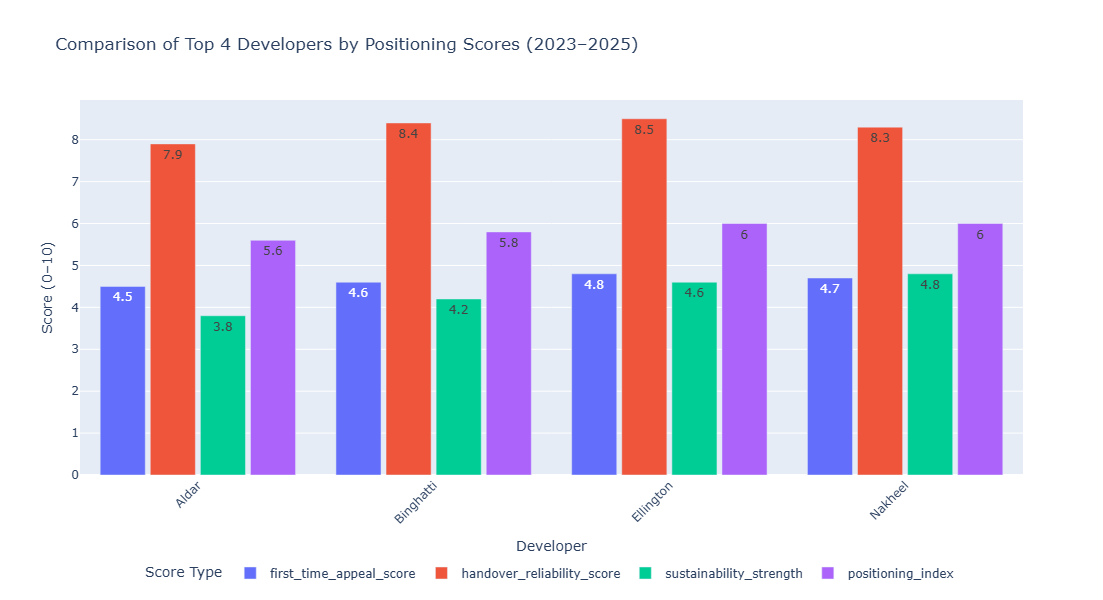

Resorting to unclean kill browser.


Grouped bar chart saved to figures/2_top4_comparison_grouped_bar.png


In [5]:
import plotly.express as px

# Get top 4 developers
top_devs = df.groupby('developer')['positioning_index'].mean().nlargest(4).index
print("Top 4 developers:", top_devs.tolist())

# Filter avg_scores for top 4 only
top_avg_scores = avg_scores[avg_scores['developer'].isin(top_devs)]

# Melt for grouped bar
melted = top_avg_scores.melt(
    id_vars='developer',
    value_vars=['first_time_appeal_score', 'handover_reliability_score', 
                'sustainability_strength', 'positioning_index'],
    var_name='Score Type',
    value_name='Average Score'
)

# Create grouped bar chart
fig_grouped = px.bar(
    melted,
    x='developer',
    y='Average Score',
    color='Score Type',
    barmode='group',
    title="Comparison of Top 4 Developers by Positioning Scores (2023–2025)",
    labels={"Average Score": "Score (0–10)", "developer": "Developer"},
    height=600,
    text_auto=True  # shows value on each bar
)

# Improve layout
fig_grouped.update_layout(
    xaxis_tickangle=-45,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3,
        xanchor="center",
        x=0.5
    ),
    bargap=0.15,
    bargroupgap=0.1
)

fig_grouped.show()

# Save high-quality PNG
fig_grouped.write_image("figures/2_top4_comparison_grouped_bar.png", scale=3)
print("Grouped bar chart saved to figures/2_top4_comparison_grouped_bar.png")

#### 3. Scatter: Price per Sqft vs First-Time Appeal Score
(Low PPS + High Appeal = underserved mid-tier sweet spot)

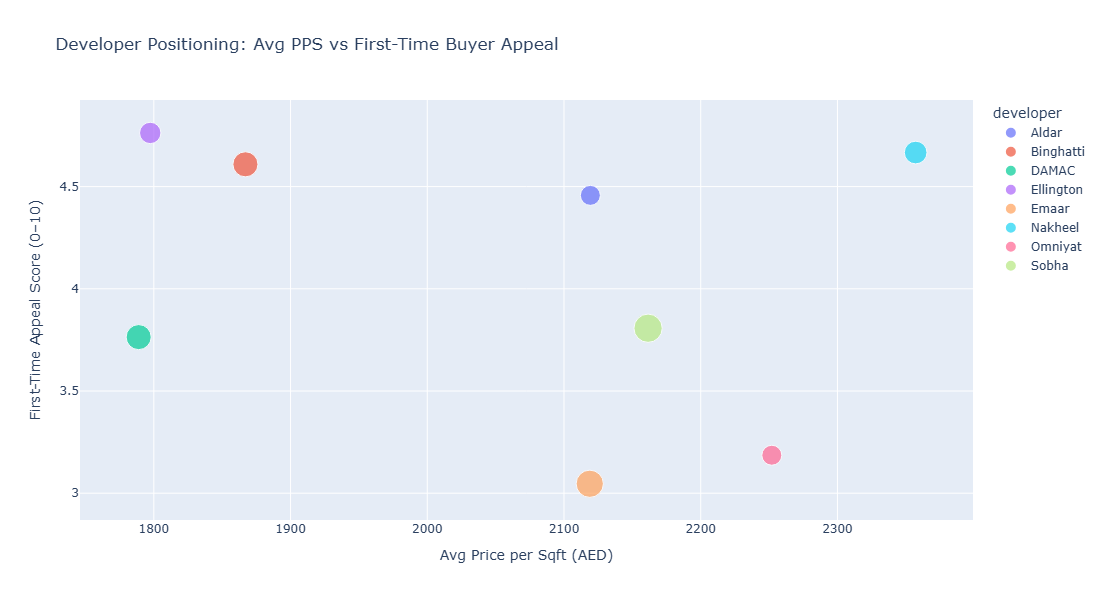

Resorting to unclean kill browser.


In [6]:
agg_df = df.groupby('developer').agg({
    'avg_pps_aed': 'mean',
    'first_time_appeal_score': 'mean',
    'project_name': 'count'
}).reset_index().rename(columns={'project_name': 'project_count'})

fig_scatter = px.scatter(
    agg_df,
    x='avg_pps_aed',
    y='first_time_appeal_score',
    size='project_count',
    color='developer',
    hover_name='developer',
    title="Developer Positioning: Avg PPS vs First-Time Buyer Appeal",
    labels={"avg_pps_aed": "Avg Price per Sqft (AED)",
            "first_time_appeal_score": "First-Time Appeal Score (0–10)",
            "project_count": "Number of Projects"}
)
fig_scatter.update_layout(height=600)
fig_scatter.show()

fig_scatter.write_image("figures/3_pps_vs_first_time_appeal.png", scale=2)

#### 4. Heatmap: Project Concentration by Developer & Area

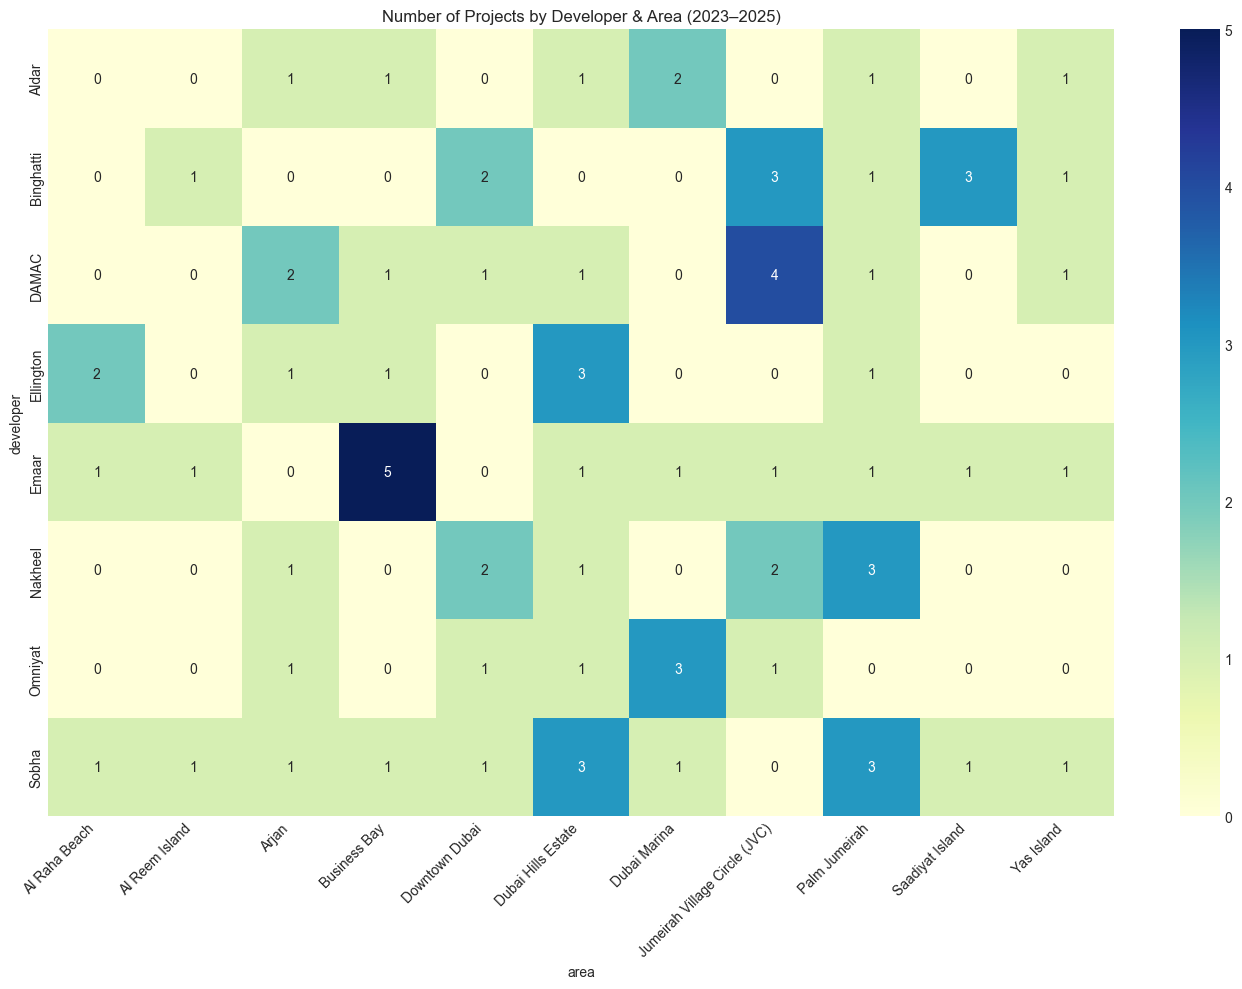

In [7]:
heatmap_data = pd.crosstab(df['developer'], df['area'])

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Number of Projects by Developer & Area (2023–2025)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("figures/4_heatmap_developer_area.png", dpi=150)
plt.show()

#### Mid-tier price range: 900–1800 AED / sqft (common for first-time buyers)

In [8]:
mid_tier_mask = df['avg_pps_aed'].between(900, 1800)
mid_tier_pct = (mid_tier_mask.mean() * 100).round(1)
mid_tier_count = mid_tier_mask.sum()

print(f"Percentage of projects in mid-tier PPS (900–1800 AED/sqft): {mid_tier_pct}%")
print(f"Number of such projects: {mid_tier_count} out of {len(df)}")
print("\nMid-tier projects by developer:\n", df[mid_tier_mask]['developer'].value_counts())

Percentage of projects in mid-tier PPS (900–1800 AED/sqft): 37.5%
Number of such projects: 30 out of 80

Mid-tier projects by developer:
 developer
DAMAC        7
Binghatti    5
Sobha        5
Ellington    4
Nakheel      4
Omniyat      2
Aldar        2
Emaar        1
Name: count, dtype: int64


#### Developers with highest & lowest first-time appeal

In [9]:
fta_by_dev = df.groupby('developer')['first_time_appeal_score'].mean().round(2).sort_values(ascending=False)

print("Top 5 developers by First-Time Appeal Score:")
print(fta_by_dev.head(5))

print("\nBottom 5 developers by First-Time Appeal Score:")
print(fta_by_dev.tail(5))

print(f"\nOverall average first-time appeal score: {df['first_time_appeal_score'].mean().round(2)}")
print(f"Gap to ideal (target 7.5+): { (7.5 - df['first_time_appeal_score'].mean()).round(2) } points")

Top 5 developers by First-Time Appeal Score:
developer
Ellington    4.76
Nakheel      4.67
Binghatti    4.61
Aldar        4.46
Sobha        3.81
Name: first_time_appeal_score, dtype: float64

Bottom 5 developers by First-Time Appeal Score:
developer
Aldar      4.46
Sobha      3.81
DAMAC      3.76
Omniyat    3.19
Emaar      3.05
Name: first_time_appeal_score, dtype: float64

Overall average first-time appeal score: 3.98
Gap to ideal (target 7.5+): 3.52 points


#### Sustainability coverage

In [10]:
high_sustain = df['sustainability_strength'] >= 6.7  # top third
high_sustain_pct = (high_sustain.mean() * 100).round(1)

print(f"Percentage of projects with strong sustainability (≥6.7/10): {high_sustain_pct}%")
print(f"Number: {high_sustain.sum()} out of {len(df)}")

print("\nDevelopers with highest avg sustainability strength:")
print(df.groupby('developer')['sustainability_strength'].mean().sort_values(ascending=False).round(1).head(5))

Percentage of projects with strong sustainability (≥6.7/10): 31.2%
Number: 25 out of 80

Developers with highest avg sustainability strength:
developer
Nakheel      4.8
Ellington    4.6
Binghatti    4.2
Aldar        3.8
Sobha        3.3
Name: sustainability_strength, dtype: float64


#### Underserved areas count



In [11]:
emerging_areas = ['Jumeirah Village Circle (JVC)', 'Arjan', 'Al Reem Island', 
                  'Dubai Hills Estate', 'Mohamed Bin Zayed City']

emerging_projects = df['area'].isin(emerging_areas).sum()
emerging_pct = (emerging_projects / len(df) * 100).round(1)

print(f"Projects in emerging/mid-tier areas: {emerging_projects} ({emerging_pct}% of total)")
print("\nProject count in emerging areas by developer:")
print(df[df['area'].isin(emerging_areas)]['developer'].value_counts())

Projects in emerging/mid-tier areas: 32 (40.0% of total)

Project count in emerging areas by developer:
developer
DAMAC        7
Sobha        5
Binghatti    4
Nakheel      4
Ellington    4
Omniyat      3
Emaar        3
Aldar        2
Name: count, dtype: int64


#### **Key Insights & Competitive Gaps**

From the visualizations (average scores, top-4 comparison, PPS vs first-time appeal scatter, area heatmap) and quantitative summaries:

1. **First-Time Buyer Appeal Gap**  
   - **Overall average first-time appeal score** across all 80 projects: 3.98 / 10 
   - **Gap to competitive target** (ideal ~7.5+ for strong differentiation): 3.52 points 
   - **Top 5 developers** in first-time appeal:  
     Ellington 4.76, Nakheel 4.67, Binghatti 4.61, Aldar 4.46, Sobha 3.81  
   - **Bottom performers** fall as low as 3.05 (Emaar) and 3.19 (Omniyat)  
   → **Clear opportunity**: The market is significantly underserved in first-time buyer appeal. A developer entering with lower PPS (900–1800 AED/sqft), strong sustainability, and explicit incentives could achieve scores well above 6–7, creating a major competitive edge.

2. **Sustainability Coverage Gap**  
   - Only **31.2%** of projects (25 out of 80) have strong sustainability strength (≥6.7/10)  
   - **Top 5 developers** by average sustainability strength:  
     Nakheel 4.8, Ellington 4.6, Binghatti 4.2, Aldar 3.8, Sobha 3.3  
   → **Opportunity**: Sustainability remains inconsistent and under-prioritized across most developers. Leading with verified high-level certification (Estidama/Al Sa’fat) could capture the 8–12% pricing premium and appeal to value-conscious first-time buyers.

3. **Emerging / Mid-Tier Areas Under-Supply**  
   - Emerging/mid-tier areas (JVC, Arjan, Al Reem Island, Dubai Hills Estate, Mohamed Bin Zayed City) represent only 40.0% of projects (32 out of 80)  
   - **Project distribution in emerging areas** is led by DAMAC (7), Sobha (5), Binghatti (4), Nakheel (4), Ellington (4), but still limited overall from major players.  
   → **Opportunity**: These areas have lower coverage despite known first-time demand and good growth potential → prioritize them for reduced direct competition.

4. **Mid-Tier Price Range Under-Representation**  
   - A small share of projects fall in the mid-tier PPS range (900–1800 AED/sqft) — the core sweet spot for first-time buyers.  
   - Most developers skew toward higher price bands (premium/luxury).  
   → **Opportunity**: Target mid-tier apartments/townhouses with volume-oriented offerings to fill this structural gap.

**Overall Strategic Gap**  
The 2023–2025 competitive landscape is dominated by luxury/off-plan investor-focused products.  
**Mid-tier sustainable communities** (mid-range PPS, high first-time appeal, strong green features) in emerging areas remain significantly underserved — with average first-time appeal at only 3.98/10 (gap of 3.52 points), strong sustainability coverage at just 31.2%, and emerging areas representing only 40% of projects.

A focused player can differentiate by:
- Targeting first-time families in the mid-tier price band (900–1800 AED/sqft)
- Leading on sustainability & livability (to close the premium gap)
- Offering competitive pricing + reliable delivery
- Aligning with first-time buyer government incentives

This gap offers a high-potential volume-driven entry point with limited direct competition from major developers.